# Prompt 4A — Initial Ensemble and Tail-Aware Experiments

This notebook reports Development Validation evidence only. It loads saved artifacts, does not train a model, does not open IID data, and does not select or freeze the final project model.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import precision_recall_curve
ROOT = Path.cwd()
REPORTS = ROOT / 'outputs' / 'reports'
PRED = ROOT / 'outputs' / 'predictions' / 'prompt4a' / 'validation'
FIGURES = ROOT / 'outputs' / 'figures' / 'prompt4a'
FIGURES.mkdir(parents=True, exist_ok=True)
design = json.loads((REPORTS / 'prompt4a_frozen_design.json').read_text(encoding='utf-8'))
summary = json.loads((ROOT / 'outputs' / 'tmp' / 'prompt4a' / 'report_summary.json').read_text(encoding='utf-8'))
print('Evidence scope: Development Validation; target unit: thousands of U.S. dollars')
print('Final model selected:', design['final_model_selected'], '| Final model frozen:', design['final_model_frozen'])

Evidence scope: Development Validation; target unit: thousands of U.S. dollars
Final model selected: False | Final model frozen: False


## 1. Objective and Prompt 4A scope

The stage compares a fixed set of saved-model ensembles and bounded Tail-Aware CatBoost systems. The results support Prompt 4B human review; they are not independent Test evidence.

## 2. Prompt 3 handoff

Prompt 2 and Prompt 3 readiness, the frozen Development source, and all seven saved Validation predictions passed the handoff checks.

In [2]:
alignment = json.loads((REPORTS / 'prompt4a_prediction_alignment.json').read_text(encoding='utf-8'))
display(pd.DataFrame(alignment['artifacts'])[['model','rows','row_order_equal','target_equal','finite_predictions','status']])

,model,rows,row_order_equal,target_equal,finite_predictions,status
0,catboost,100000,True,True,True,PASS
1,lightgbm,100000,True,True,True,PASS
2,xgboost,100000,True,True,True,PASS
3,histgradientboosting,100000,True,True,True,PASS
4,lasso,100000,True,True,True,PASS
5,realmlp,100000,True,True,True,PASS
6,fttransformer,100000,True,True,True,PASS


## 3. Validation selection/audit split

The 100,000 Validation rows have a fixed 70,000-row selection role and a 30,000-row audit role. Audit rows did not optimize weights or choose preliminary references.

In [3]:
display(pd.DataFrame([json.loads((REPORTS / 'prompt4a_validation_split.json').read_text(encoding='utf-8'))]))

,status,created_at_utc,random_state,stratification,source_validation_rows,selection_rows,audit_rows,selection_audit_overlap,source_validation_row_hash_digest,selection_row_hash_digest,audit_row_hash_digest,decile_label_count
0,PASS,2026-08-06T17:52:30.881736+00:00,42,duplicate-safe target deciles,100000,70000,30000,0,676b577233627c8b237d214a29eeb798e099d028583c8b...,3af54200bbda79bbe910903b4a32c217d409b19b07cf0f...,f7dcb7ee23049a24564f474f5e1730dde756bf22158e7c...,10


## 4. Seven saved single models

Single-model results use original-scale predictions. Lower MAE is the primary preliminary criterion.

In [4]:
single = pd.read_csv(REPORTS / 'prompt4a_single_model_results.csv')
single_complete = single.query("scope == 'complete_validation'").sort_values('mae')
display(single_complete[['candidate_id','mae','rmse','bottom_90_mae','top_decile_mae','top_five_percent_mae','mean_signed_error']])

,candidate_id,mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,mean_signed_error
2,catboost,62.660954,126.795248,47.959194,194.785914,279.640881,-7.755353
8,xgboost,63.243238,126.088854,47.708510,202.854094,286.992072,-14.758532
5,lightgbm,63.296230,125.698421,48.590078,195.460670,280.182225,-7.097795
11,histgradientboosting,64.137294,129.547701,49.060585,199.631925,287.125002,-8.953090
20,fttransformer,65.809259,136.059498,49.128532,215.719239,309.344671,-19.521765
17,realmlp,66.367403,125.895709,52.392650,191.958740,268.516404,0.019098
14,lasso,70.348448,137.513190,52.768391,228.340719,325.416109,-18.245237


## 5. Prediction diversity

Correlation and mean absolute prediction differences describe diversity only. They did not add Candidates.

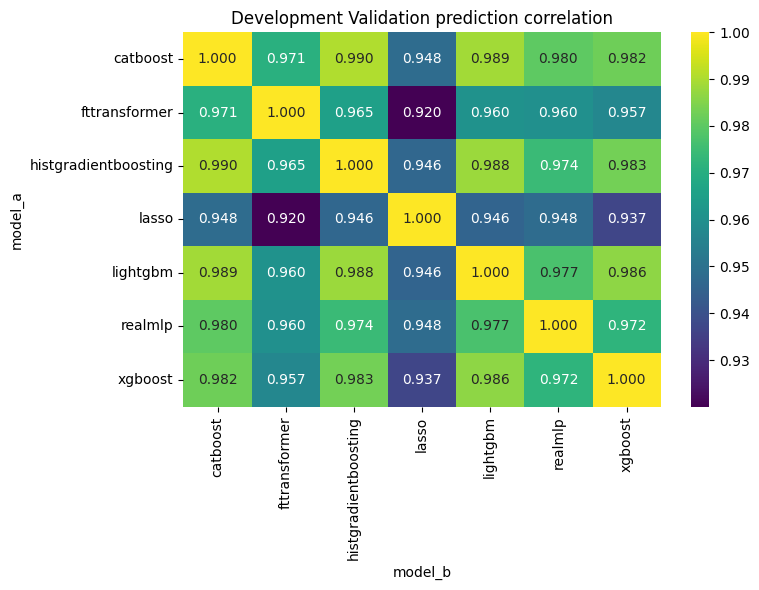

,model_a,model_b,metric,value
0,catboost,catboost,pearson_correlation,1.000000
1,catboost,catboost,spearman_correlation,1.000000
2,catboost,catboost,mean_absolute_difference,0.000000
3,catboost,lightgbm,pearson_correlation,0.988960
4,catboost,lightgbm,spearman_correlation,0.991736
5,catboost,lightgbm,mean_absolute_difference,13.188189
6,catboost,xgboost,pearson_correlation,0.982468
7,catboost,xgboost,spearman_correlation,0.989935
8,catboost,xgboost,mean_absolute_difference,16.075041
9,catboost,histgradientboosting,pearson_correlation,0.990453


In [5]:
corr = pd.read_csv(REPORTS / 'prompt4a_prediction_correlations.csv')
pearson = corr.query("metric == 'pearson_correlation'").pivot(index='model_a',columns='model_b',values='value')
plt.figure(figsize=(8,6)); sns.heatmap(pearson,annot=True,fmt='.3f',cmap='viridis'); plt.title('Development Validation prediction correlation'); plt.tight_layout(); plt.savefig(FIGURES/'prediction_correlation.png',dpi=140); plt.show()
display(corr.head(12))

## 6. Boosting-only ensembles

These blends use only saved CatBoost, LightGBM, and XGBoost predictions.

## 7. Boosting/Deep ensembles

The mixed Candidates combine saved boosting and Deep predictions without refitting any prior model.

## 8. Convex ensembles

Two deterministic constrained optimizations used only the selection rows, one equal initialization, and non-negative weights summing to one.

In [6]:
weights = pd.read_csv(REPORTS / 'prompt4a_ensemble_weights.csv')
display(weights)
print('Maximum absolute weight-sum error:', weights.query("status == 'COMPLETE'").groupby('candidate_id').weight.sum().sub(1).abs().max())

,candidate_id,member,weight,status,solver_status
0,ens_boost_equal,catboost,3.333333e-01,COMPLETE,NOT_REQUIRED
1,ens_boost_equal,lightgbm,3.333333e-01,COMPLETE,NOT_REQUIRED
2,ens_boost_equal,xgboost,3.333333e-01,COMPLETE,NOT_REQUIRED
3,ens_boost_cat050,catboost,5.000000e-01,COMPLETE,NOT_REQUIRED
4,ens_boost_cat050,lightgbm,2.500000e-01,COMPLETE,NOT_REQUIRED
5,ens_boost_cat050,xgboost,2.500000e-01,COMPLETE,NOT_REQUIRED
6,ens_boost_cat060,catboost,6.000000e-01,COMPLETE,NOT_REQUIRED
7,ens_boost_cat060,lightgbm,2.000000e-01,COMPLETE,NOT_REQUIRED
8,ens_boost_cat060,xgboost,2.000000e-01,COMPLETE,NOT_REQUIRED
9,ens_cat_ft_equal,catboost,5.000000e-01,COMPLETE,NOT_REQUIRED


Maximum absolute weight-sum error: 0.0


## 9. Preliminary ensemble ranking

The preliminary ensemble reference was chosen on selection rows only and remains open to Prompt 4B review.

In [7]:
ensembles = pd.read_csv(REPORTS / 'prompt4a_ensemble_results.csv')
display(ensembles.query("scope == 'complete_validation' and status == 'COMPLETE'").sort_values('mae')[['candidate_id','mae','rmse','bottom_90_mae','top_decile_mae','top_five_percent_mae']])
print('Selection-only preliminary ensemble:', summary['best_ensemble_4a'])

,candidate_id,mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae
29,ens_convex_boosting_deep,62.263797,125.829968,47.291129,196.823415,281.664308
26,ens_convex_boosting,62.329971,125.301853,47.465720,195.915244,279.960309
5,ens_boost_cat050,62.351851,125.208984,47.540946,195.457706,279.532523
8,ens_boost_cat060,62.356316,125.418232,47.576966,195.178575,279.352393
23,ens_boost_ft_equal,62.397375,126.262860,47.234438,198.666949,284.314300
2,ens_boost_equal,62.412510,124.981783,47.536850,196.100313,280.079463
17,ens_cat_lgb_ft,62.621536,128.116656,47.366838,199.715763,286.990826
20,ens_cat_ft_realmlp,62.942164,127.622127,47.868447,198.409914,283.609129
11,ens_cat_ft_equal,62.952333,129.645405,47.473324,202.062449,290.472873
14,ens_cat_realmlp_equal,63.562304,124.787324,49.347873,191.307630,271.162409


Selection-only preliminary ensemble: ens_boost_cat060


## 10. Train-derived Tail definition

The operational Tail threshold came only from the 400,000 Train targets. Operational Tail membership is strictly above this threshold.

In [8]:
display(pd.DataFrame([json.loads((REPORTS / 'prompt4a_tail_definition.json').read_text(encoding='utf-8'))]).drop(columns=['internal_split']))

,status,created_at_utc,q90_train,definition,source_role,train_tail_rows,train_tail_proportion,validation_above_q90_train,train_tied_at_q90,validation_tied_at_q90
0,PASS,2026-08-06T17:52:30.893761+00:00,438.0,loan_amount_000s > q90_train,train,39897,0.099742,9974,120,39


## 11. Tail Gate design

One CatBoost classifier predicts the chance that a row exceeds the frozen Train q90 threshold. It uses the same 35 non-sensitive, no-lender features.

## 12. Gate performance

Gate discrimination and threshold behavior are descriptive Development Validation results.

,scope,rows,pr_auc,roc_auc,brier_score,threshold,precision,recall,f1,false_negative_rate,predicted_tail_proportion
0,selection,70000,0.795170,0.968384,0.071419,0.35,0.433309,0.950587,0.595273,0.049413,0.218814
1,selection,70000,0.795170,0.968384,0.071419,0.50,0.497899,0.916500,0.645256,0.083500,0.183600
2,selection,70000,0.795170,0.968384,0.071419,0.65,0.570246,0.868519,0.688465,0.131481,0.151914
3,audit,30000,0.798393,0.968513,0.070954,0.35,0.431105,0.950535,0.593180,0.049465,0.219900
4,audit,30000,0.798393,0.968513,0.070954,0.50,0.499909,0.919452,0.647675,0.080548,0.183433
5,audit,30000,0.798393,0.968513,0.070954,0.65,0.575221,0.868984,0.692226,0.131016,0.150667
6,complete_validation,100000,0.796098,0.968421,0.071279,0.35,0.432646,0.950571,0.594644,0.049429,0.219140
7,complete_validation,100000,0.796098,0.968421,0.071279,0.50,0.498502,0.917385,0.645981,0.082615,0.183550
8,complete_validation,100000,0.796098,0.968421,0.071279,0.65,0.571730,0.868659,0.689589,0.131341,0.151540


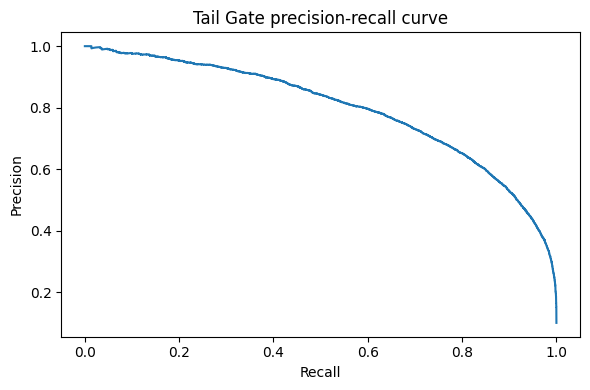

In [9]:
gate_metrics = pd.read_csv(REPORTS / 'prompt4a_gate_metrics.csv')
display(gate_metrics)
gate = pd.read_parquet(PRED / 'tail_gate.parquet')
precision, recall, _ = precision_recall_curve(gate.operational_tail_true.astype(int), gate.p_tail)
plt.figure(figsize=(6,4)); plt.plot(recall,precision); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Tail Gate precision-recall curve'); plt.tight_layout(); plt.savefig(FIGURES/'gate_precision_recall.png',dpi=140); plt.show()

## 13. Tail Specialist design

The Specialist was selected with Train-only Tail rows and then refitted on all operational Tail rows in Train.

In [10]:
specialist = json.loads((REPORTS / 'prompt4a_specialist_metrics.json').read_text(encoding='utf-8'))
display(pd.DataFrame(specialist['rows']))

,candidate_id,scope,operational_tail_only,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,top_five_percent_rows,boundary_rows,operational_tail_rows,operational_body_rows,operational_tail_mae,operational_body_mae,operational_tail_signed_error,operational_body_signed_error,operational_tail_underprediction_rate,operational_body_underprediction_rate
0,tail_specialist,selection,True,6982,146.736259,305.153850,0.507895,0.244611,71.105867,333.044922,...,350,698,6982,63018,146.736259,290.681074,-36.537301,290.680119,0.493555,0.000016
1,tail_specialist,audit,True,2992,140.268972,278.023351,0.492219,0.242353,68.647940,323.481947,...,150,299,2992,27008,140.268972,290.559898,-35.067564,290.559898,0.506016,0.000000
2,tail_specialist,complete_validation,True,9974,144.796202,297.275332,0.503950,0.243936,70.228574,329.967848,...,499,1000,9974,90026,144.796202,290.644721,-36.096409,290.644052,0.497293,0.000011


## 14. Tail-weighted Global models

Two fixed CatBoost models give operational Tail rows weight 2 or 4 while keeping body-row weight 1.

In [11]:
weighted = pd.read_csv(REPORTS / 'prompt4a_tail_weighted_results.csv')
display(weighted.query("scope == 'complete_validation'")[['candidate_id','mae','rmse','bottom_90_mae','top_decile_mae','top_five_percent_mae','top_decile_signed_error']])

,candidate_id,mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,top_decile_signed_error
2,tail_weighted_catboost_w2,62.667163,126.077693,48.098114,193.599449,278.346715,-135.023494
5,tail_weighted_catboost_w4,62.717454,125.641561,48.207541,193.118280,277.874985,-135.484808


## 15. Hard-routing results

Hard routing sends rows above a fixed Gate probability threshold to the Tail Specialist.

In [12]:
hard = pd.read_csv(REPORTS / 'prompt4a_hard_routing_results.csv')
hard_complete = hard.query("scope == 'complete_validation'")
display(hard_complete[['candidate_id','global_base','mae','rmse','routed_percentage','true_tail_recall','false_routing_rate','top_decile_mae']])

,candidate_id,global_base,mae,rmse,routed_percentage,true_tail_recall,false_routing_rate,top_decile_mae
2,hard_global_best_single_t035,global_best_single,74.225000,138.935856,21.914,0.950571,0.138105,154.190864
5,hard_global_best_single_t050,global_best_single,70.125674,133.637505,18.355,0.917385,0.102248,159.152924
8,hard_global_best_single_t065,global_best_single,67.079195,129.763958,15.154,0.868659,0.072090,165.493398
11,hard_global_best_ensemble_t035,global_best_ensemble,74.106664,138.884577,21.914,0.950571,0.138105,154.275961
14,hard_global_best_ensemble_t050,global_best_ensemble,69.995597,133.570054,18.355,0.917385,0.102248,159.314677
17,hard_global_best_ensemble_t065,global_best_ensemble,66.937715,129.688032,15.154,0.868659,0.072090,165.781022


## 16. Soft-mixture results

Soft mixtures apply a probability-weighted correction with one of three frozen alpha values.

In [13]:
soft = pd.read_csv(REPORTS / 'prompt4a_soft_mixture_results.csv')
soft_complete = soft.query("scope == 'complete_validation'")
display(soft_complete[['candidate_id','global_base','alpha','mae','rmse','mean_absolute_correction','p95_absolute_correction','top_decile_mae']])

,candidate_id,global_base,alpha,mae,rmse,mean_absolute_correction,p95_absolute_correction,top_decile_mae
2,soft_global_best_single_a050,global_best_single,0.50,64.131318,125.593065,13.695606,59.847568,170.423534
5,soft_global_best_single_a075,global_best_single,0.75,66.174151,127.143295,20.543409,89.771352,161.926992
8,soft_global_best_single_a100,global_best_single,1.00,68.928833,130.075194,27.391212,119.695136,156.590847
11,soft_global_best_ensemble_a050,global_best_ensemble,0.50,63.797954,124.748176,13.891765,60.539441,170.602461
14,soft_global_best_ensemble_a075,global_best_ensemble,0.75,65.858498,126.600575,20.837647,90.809162,162.070985
17,soft_global_best_ensemble_a100,global_best_ensemble,1.00,68.658074,129.844437,27.783529,121.078882,156.776458


## 17. Bottom-90% and Tail trade-offs

This plot shows whether Tail improvements create material body error.

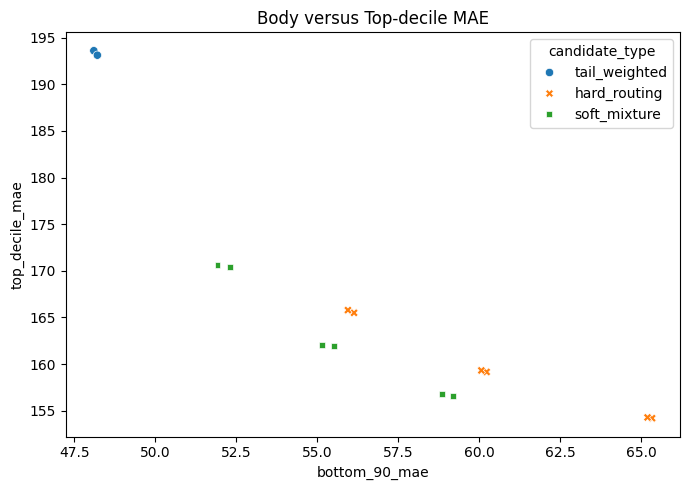

In [14]:
trade = pd.concat([weighted.query("scope == 'complete_validation'"),hard_complete,soft_complete],ignore_index=True)
plt.figure(figsize=(7,5)); sns.scatterplot(data=trade,x='bottom_90_mae',y='top_decile_mae',hue='candidate_type',style='candidate_type'); plt.title('Body versus Top-decile MAE'); plt.tight_layout(); plt.savefig(FIGURES/'body_tail_tradeoff.png',dpi=140); plt.show()

## 18. Boundary-region analysis

P85-to-P95 MAE checks behavior near the Tail boundary.

In [15]:
display(trade.sort_values('p85_to_p95_boundary_mae')[['candidate_id','candidate_type','p85_to_p95_boundary_mae','mae','top_decile_mae']].head(15))

,candidate_id,candidate_type,p85_to_p95_boundary_mae,mae,top_decile_mae
8,soft_global_best_single_a050,soft_mixture,86.124591,64.131318,170.423534
9,soft_global_best_single_a075,soft_mixture,86.400521,66.174151,161.926992
11,soft_global_best_ensemble_a050,soft_mixture,86.464834,63.797954,170.602461
12,soft_global_best_ensemble_a075,soft_mixture,86.625551,65.858498,162.070985
10,soft_global_best_single_a100,soft_mixture,90.596889,68.928833,156.590847
13,soft_global_best_ensemble_a100,soft_mixture,90.860490,68.658074,156.776458
1,tail_weighted_catboost_w4,tail_weighted,97.528768,62.717454,193.118280
0,tail_weighted_catboost_w2,tail_weighted,97.900707,62.667163,193.599449
2,hard_global_best_single_t035,hard_routing,108.588489,74.225000,154.190864
5,hard_global_best_ensemble_t035,hard_routing,109.017049,74.106664,154.275961


## 19. Provisional acceptance diagnostics

These checks are diagnostic only and cannot select the final model.

,candidate_id,candidate_type,global_base,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
0,tail_weighted_catboost_w2,tail_weighted,catboost,False,False,False,True,True,True,3,6,PARTIAL
1,tail_weighted_catboost_w4,tail_weighted,catboost,False,False,False,True,True,False,2,6,PARTIAL
2,hard_global_best_single_t035,hard_routing,global_best_single,False,True,False,False,True,True,3,6,PARTIAL
3,hard_global_best_single_t050,hard_routing,global_best_single,False,True,False,False,True,True,3,6,PARTIAL
4,hard_global_best_single_t065,hard_routing,global_best_single,False,True,False,False,True,True,3,6,PARTIAL
5,soft_global_best_single_a050,soft_mixture,global_best_single,False,True,False,True,True,True,4,6,PARTIAL
6,soft_global_best_single_a075,soft_mixture,global_best_single,False,True,False,False,True,True,3,6,PARTIAL
7,soft_global_best_single_a100,soft_mixture,global_best_single,False,True,False,False,True,True,3,6,PARTIAL
8,hard_global_best_ensemble_t035,hard_routing,global_best_ensemble,False,True,False,False,True,True,3,6,PARTIAL
9,hard_global_best_ensemble_t050,hard_routing,global_best_ensemble,False,True,False,False,True,True,3,6,PARTIAL


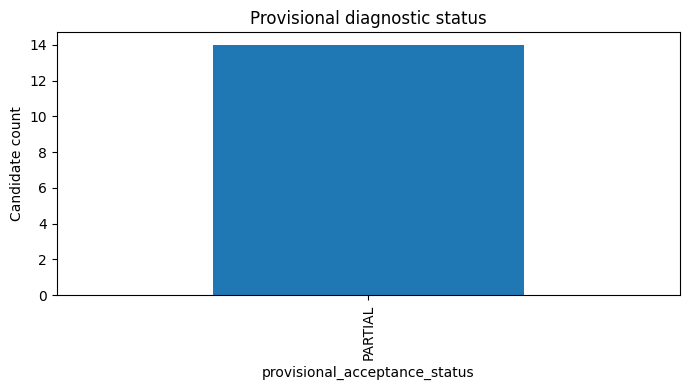

In [16]:
acceptance = pd.read_csv(REPORTS / 'prompt4a_provisional_acceptance.csv')
display(acceptance)
plt.figure(figsize=(7,4)); acceptance.provisional_acceptance_status.value_counts().plot(kind='bar'); plt.ylabel('Candidate count'); plt.title('Provisional diagnostic status'); plt.tight_layout(); plt.savefig(FIGURES/'provisional_acceptance.png',dpi=140); plt.show()

## 20. Descriptive bootstrap

The paired bootstrap compares preliminary references on the same 100,000 Development Validation rows. It is not independent Test evidence.

In [17]:
bootstrap = json.loads((REPORTS / 'prompt4a_bootstrap.json').read_text(encoding='utf-8'))
display(pd.DataFrame(bootstrap['comparisons']).T.reset_index(names='candidate_id'))

,candidate_id,rows,n_resamples,random_state,mae_difference,percentile_2_5,median,percentile_97_5,win_proportion
0,catboost,100000.0,300.0,42.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,ens_boost_cat060,100000.0,300.0,42.0,-0.304638,-0.372797,-0.310844,-0.236148,1.000000
2,tail_weighted_catboost_w4,100000.0,300.0,42.0,0.056500,-0.039266,0.052502,0.129332,0.093333
3,hard_global_best_single_t065,100000.0,300.0,42.0,4.418241,4.124354,4.424257,4.705032,0.000000
4,soft_global_best_ensemble_a050,100000.0,300.0,42.0,1.137000,0.970818,1.136014,1.302632,0.000000


## 21. Runtime and artifact summary

All six scientific fits ran sequentially. Saved bundles and predictions are reusable experimental artifacts, not final project bundles.

In [18]:
runtime = json.loads((REPORTS / 'prompt4a_runtime.json').read_text(encoding='utf-8'))
models = json.loads((REPORTS / 'prompt4a_model_manifest.json').read_text(encoding='utf-8'))
predictions = json.loads((REPORTS / 'prompt4a_prediction_manifest.json').read_text(encoding='utf-8'))
display(pd.DataFrame([runtime])); display(pd.DataFrame(models['artifacts'])[['bundle','path','status']]); print('Prediction artifacts:', predictions['artifact_count'])

,status,created_at_utc,scientific_fit_count,scientific_fit_attempt_count,scientific_fits_sequential,smoke_attempts,model_storage_bytes,prediction_storage_bytes,raw_access_count,iid_feature_access_count,iid_target_access_count
0,PASS,2026-08-06T18:59:37.597371+00:00,6,6,True,1,156796120,117688530,0,0,0


,bundle,path,status
0,tail_gate,outputs/models/prompt4a/tail_gate,PASS
1,tail_specialist,outputs/models/prompt4a/tail_specialist,PASS
2,tail_weighted_catboost_w2,outputs/models/prompt4a/tail_weighted_catboost_w2,PASS
3,tail_weighted_catboost_w4,outputs/models/prompt4a/tail_weighted_catboost_w4,PASS


Prediction artifacts: 26


## 22. Verification

The final verification checks fit isolation, alignment, reload, notebook safety, access closure, and no-freeze status.

In [19]:
verification_path = REPORTS / 'prompt4a_verification.json'
if verification_path.exists():
    verification = json.loads(verification_path.read_text(encoding='utf-8')); display(pd.DataFrame([verification['checks']]).T.reset_index(names='check'))
else:
    print('Final verification is written after notebook execution and independent review.')

Final verification is written after notebook execution and independent review.


## 23. Limitations

Development Validation supported model development, so it is not an independent Test set. Tail probabilities are predictive scores, not causal or fairness evidence. Weak Tail results remain valid experimental outcomes.

## 24. Prompt 4B handoff

Prompt 4A makes no final-model claim. Human review should inspect the saved-single, ensemble, Tail-weighted, hard-routing, and soft-mixture trade-offs before designing Prompt 4B.

,group,candidate_id,mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,top_decile_signed_error,top_decile_underprediction_rate
0,saved single,catboost,62.660954,126.795248,47.959194,194.785914,279.640881,-137.805046,0.786478
9,no-fit ensemble,ens_boost_cat060,62.356316,125.418232,47.576966,195.178575,279.352393,-139.054319,0.793968
18,Tail-weighted,tail_weighted_catboost_w4,62.717454,125.641561,48.207541,193.118280,277.874985,-135.484808,0.789574
21,hard routing,hard_global_best_single_t065,67.079195,129.763958,56.128486,165.493398,227.707138,-62.013418,0.564766
28,soft mixture,soft_global_best_ensemble_a050,63.797954,124.748176,51.913643,170.602461,250.567117,-99.799143,0.716668


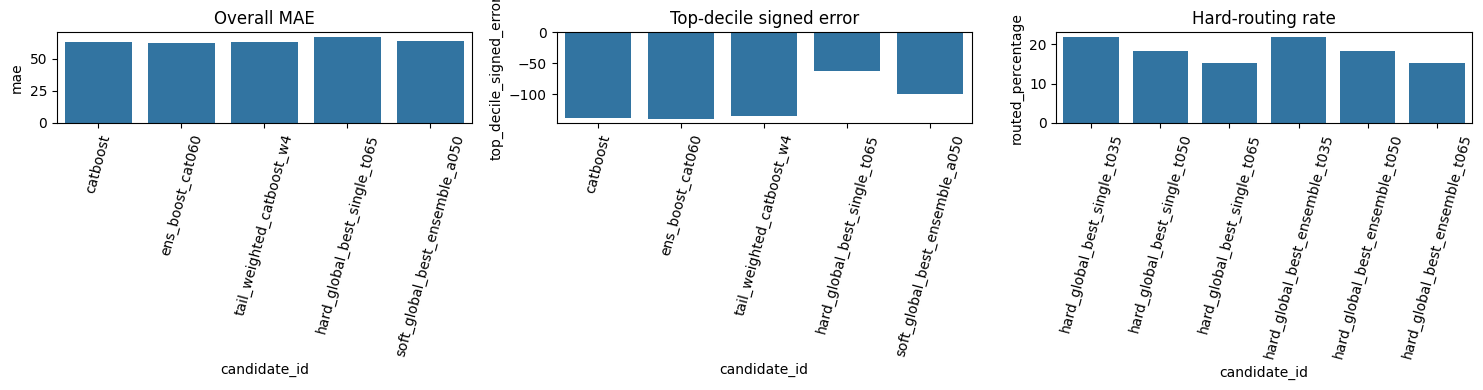

In [20]:
comparison = pd.concat([single_complete.assign(group='saved single'), ensembles.query("scope == 'complete_validation' and status == 'COMPLETE'").assign(group='no-fit ensemble'), weighted.query("scope == 'complete_validation'").assign(group='Tail-weighted'), hard_complete.assign(group='hard routing'), soft_complete.assign(group='soft mixture')],ignore_index=True)
chosen = [summary['best_saved_single'],summary['best_ensemble_4a'],summary['best_tail_weighted'],summary['best_hard_routing'],summary['best_soft_mixture']]
display(comparison[comparison.candidate_id.isin(chosen)][['group','candidate_id','mae','rmse','bottom_90_mae','top_decile_mae','top_five_percent_mae','top_decile_signed_error','top_decile_underprediction_rate']])
fig, axes = plt.subplots(1,3,figsize=(15,4)); sns.barplot(data=comparison[comparison.candidate_id.isin(chosen)],x='candidate_id',y='mae',ax=axes[0]); sns.barplot(data=comparison[comparison.candidate_id.isin(chosen)],x='candidate_id',y='top_decile_signed_error',ax=axes[1]); sns.barplot(data=hard_complete,x='candidate_id',y='routed_percentage',ax=axes[2]); [ax.tick_params(axis='x',rotation=75) for ax in axes]; axes[0].set_title('Overall MAE'); axes[1].set_title('Top-decile signed error'); axes[2].set_title('Hard-routing rate'); plt.tight_layout(); plt.savefig(FIGURES/'human_review_summary.png',dpi=140); plt.show()